# LSTM model for Ticker Forecasting with pyTorch

TODO: reproducibility

In [1]:
import numpy as np
import yfinance as yf

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [3]:
import utils

In [4]:
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)['lstm']

# frequently used params
ticker = params['ticker']
date_start = params['date_start']
date_end = params['date_end']
seq_length = params['seq_length']

utils.print_params(params)


ticker: AAPL
date_start: 2020-01-01
date_end: 2026-01-01
seq_length: 30
input_dim: 1
hidden_dim: 32
num_layers: 2
output_dim: 1
learning_rate: 0.01
epochs: 200
random_state: 42


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
# reproducibility
#https://docs.pytorch.org/docs/stable/notes/randomness.html
foo = torch.manual_seed(params['random_state'])

## Dataset

### Load

In [7]:
df = yf.download(ticker, start=date_start, end=date_end)

[*********************100%***********************]  1 of 1 completed


In [8]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


<Axes: xlabel='Date'>

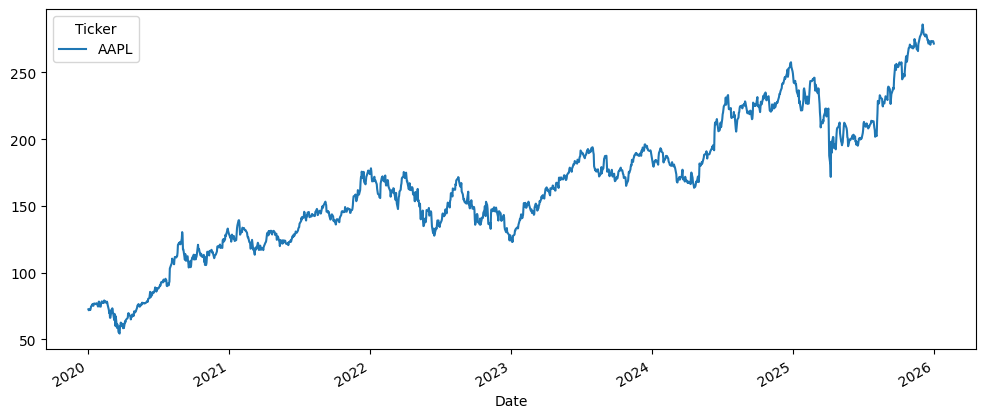

In [9]:
df['Close'].plot(figsize=(12, 5))

### Prepare

In [10]:
scaler = StandardScaler()
df['Close'] = scaler.fit_transform(df['Close'])

In [11]:
data = []

# list of overlapping sequences
for i in range(len(df) - seq_length):
    data.append(df['Close'][i: i + seq_length])

data = np.array(data)
data.shape

(1478, 30, 1)

In [12]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device) # ...
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [13]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([1182, 29, 1]),
 torch.Size([1182, 1]),
 torch.Size([296, 29, 1]),
 torch.Size([296, 1]))

## Model

### Build (architecture)

In [14]:
from typing import Any


class LSTMNet(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMNet, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [15]:
model = LSTMNet(
    input_dim=params['input_dim'],
    hidden_dim=params['hidden_dim'],
    num_layers=params['num_layers'],
    output_dim=params['output_dim']
).to(device)

### Compile

In [16]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'])

In [17]:
print(model)

LSTMNet(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Training loop (fit)

In [18]:
# for plotting
losses = []

for epoch in range(1, params['epochs'] + 1):
#    model.train()  # training mode
#    running_loss = 0.0

    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)
    losses.append(loss.item())

    if epoch % 25 == 0:
        print(f"Epoch {epoch}/{params['epochs']}: Loss was {loss}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 25/200: Loss was 0.010102144442498684
Epoch 50/200: Loss was 0.005222648847848177
Epoch 75/200: Loss was 0.004656385164707899
Epoch 100/200: Loss was 0.004332592245191336
Epoch 125/200: Loss was 0.004063891246914864
Epoch 150/200: Loss was 0.003823433304205537
Epoch 175/200: Loss was 0.0036088742781430483
Epoch 200/200: Loss was 0.003421280300244689


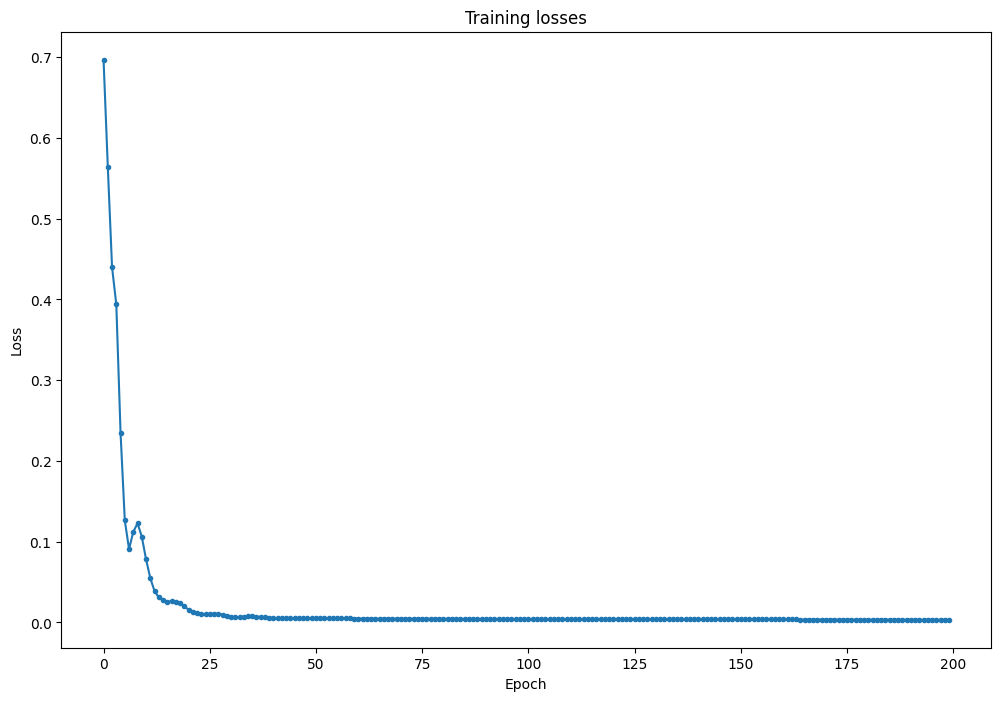

In [19]:
ax = utils.plot_train_losses(params['epochs'], losses)

## Results

### Evaluation (RMSE)

In [20]:
model.eval()

y_test_pred = model(X_test)

y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())

y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())

In [21]:
y_train.shape, y_train_pred.shape, y_test.shape, y_test_pred.shape

((1182, 1), (1182, 1), (296, 1), (296, 1))

In [22]:
y_train[:, 0].shape

(1182,)

In [23]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [24]:
train_rmse, test_rmse

(2.904447078704834, 8.216595649719238)

### Show

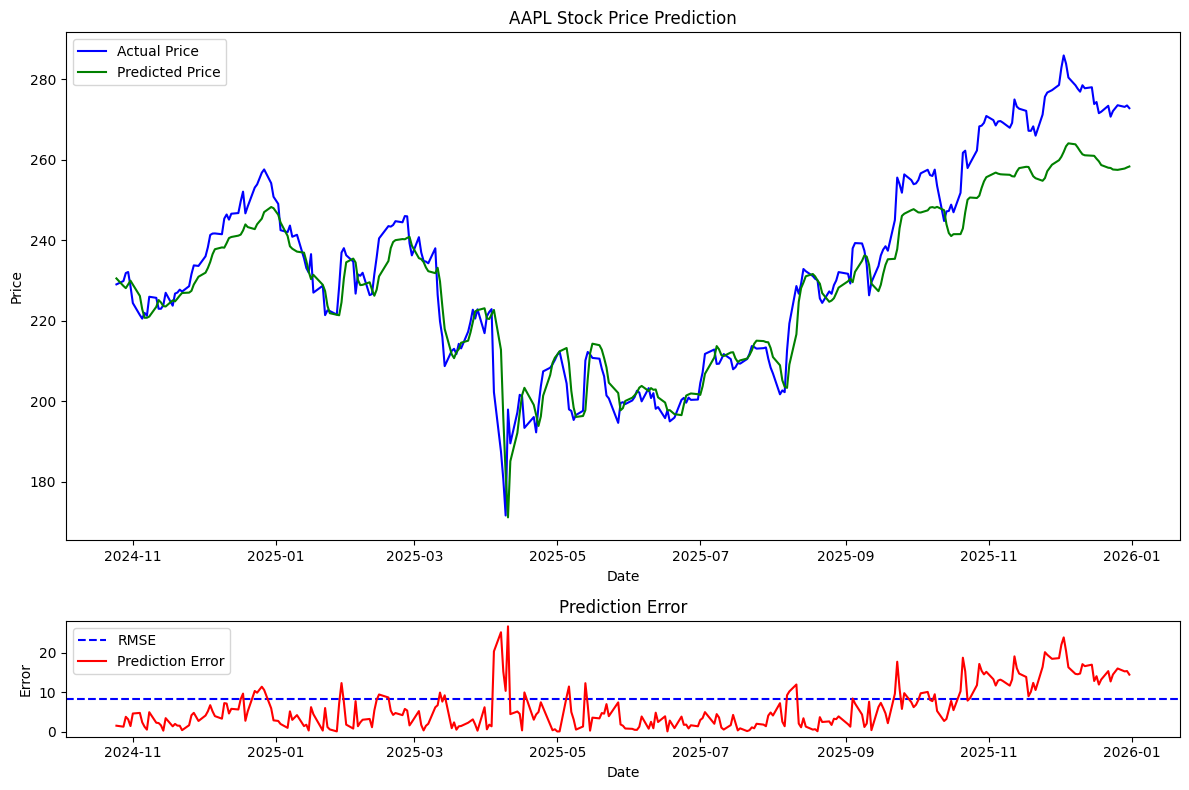

In [25]:
foo = utils.plot_stock_prediction(y_test, y_test_pred, df, test_rmse, ticker)